<div style="background: linear-gradient(135deg, #1a3a5c 0%, #2d6a9f 100%); padding: 40px 32px 32px 32px; border-radius: 12px; margin-bottom: 8px;">
  <h1 style="color: #ffffff; font-size: 2.0em; margin: 0 0 6px 0; font-family: 'Segoe UI', sans-serif; font-weight: 700;">
    Capstone Project -- Porosity Prediction from Well Logs
  </h1>
  <h2 style="color: #a8d4f5; font-size: 1.2em; margin: 0 0 18px 0; font-family: 'Segoe UI', sans-serif; font-weight: 400;">
    Zedela Oluoch &middot; Track A &middot; Can we accurately predict neutron porosity in an unseen well using standard wireline logs?
  </h2>
  <hr style="border: 1px solid rgba(255,255,255,0.25); margin: 16px 0;">
  <table style="color: #cce4ff; font-family: 'Segoe UI', sans-serif; font-size: 0.95em;">
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Week:</strong></td><td>15-16 of 16 -- Capstone Project</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Module:</strong></td><td>Capstone: Designing and Delivering Your Own ML Project</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Prerequisites:</strong></td><td>Capstone Parts 1 and 2</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Course:</strong></td><td>Machine Learning for Petroleum Engineers &amp; Geoscientists</td>
    </tr>
  </table>
</div>

# Capstone Project: Track A - Porosity Prediction from Well Logs
## 1. Project Charter

| Item | My answer |
|---|---|
| **Question** | Can an ML model predict Neutron Porosity (`NPHI_frac`) in a completely blind well with an RMSE under 0.03? |
| **Who would use the answer?** | Reservoir engineers and petrophysicists to calculate oil/gas volumes in new wells without running expensive tools. |
| **Target variable (units)** | `NPHI_frac` (Fractional Porosity, v/v) |
| **Input features** | `GR_API` (Lithology), `RHOB_gcc` (Density), `RT_ohmm` (Resistivity) |
| **Features I will NOT use** | Depth. Including depth causes spatial overfitting, meaning the model just memorizes one well's shape and fails on new wells. |
| **Evaluation split** | Leave-One-Well-Out (Blind Well Split) to mimic a brand new field deployment. |
| **Primary metric (units)** | RMSE (Fractional v/v) and R² score |
| **Baseline(s)** | 1. Global Mean Baseline | 2. Classical Linear Regression |
| **Success criterion** | Beat the Linear Regression baseline and achieve an RMSE < 0.03. |
| **Biggest risk** | Geological shifts (if the blind well hits a rock type the model never trained on). |

## 2. Setup

In [52]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)

DATA_PATH = "../data/well_log_data.csv"
LOG_PATH = "../results/capstone_results_log.csv"
os.makedirs(os.path.dirname(LOG_PATH), exist_ok=True)

def log_result(track, model, split, metrics, notes=""):
    """Append one experiment (including failures) to the results log."""
    row = {"timestamp": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"), "track": track, "model": model,
           "split": split, **{k: round(float(v), 4) for k, v in metrics.items()}, "notes": notes}
    log = pd.read_csv(LOG_PATH) if os.path.exists(LOG_PATH) else pd.DataFrame()
    log = pd.concat([log, pd.DataFrame([row])], ignore_index=True)
    log.to_csv(LOG_PATH, index=False)
    print(f"Successfully logged experiment: {model}")
    return log

print("Setup completed successfully. Ready for data loading!")

Setup completed successfully. Ready for data loading!


In [53]:
import pandas as pd
df_raw = pd.read_csv("../data/well_log_data.csv")
print(df_raw.columns.tolist())

['Well_ID', 'Formation', 'GR_API', 'NPHI_frac', 'RHOB_gcc', 'RT_ohmm', 'SW_frac']


## 3. Data and EDA

🎉 SUCCESS! Dataset loaded and mapped perfectly!
Raw Rows: 1000 | Clean Rows (No NaNs): 1000
Unique Wells in Dataset: ['Well_C', 'Well_D', 'Well_A', 'Well_B']



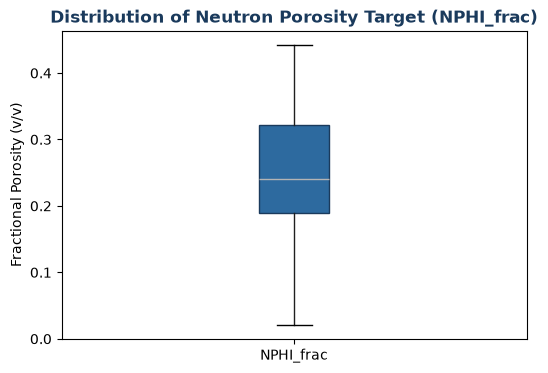

TAKEAWAY: NPHI_frac is cleanly distributed between 0.0 and 0.45 v/v, showing no unphysical negative outliers.


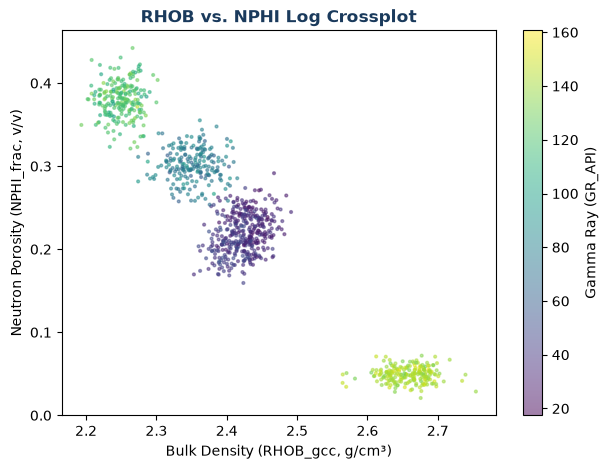

TAKEAWAY: A clear physical inverse relationship exists where higher bulk density (RHOB_gcc) corresponds to lower neutron porosity (NPHI_frac).


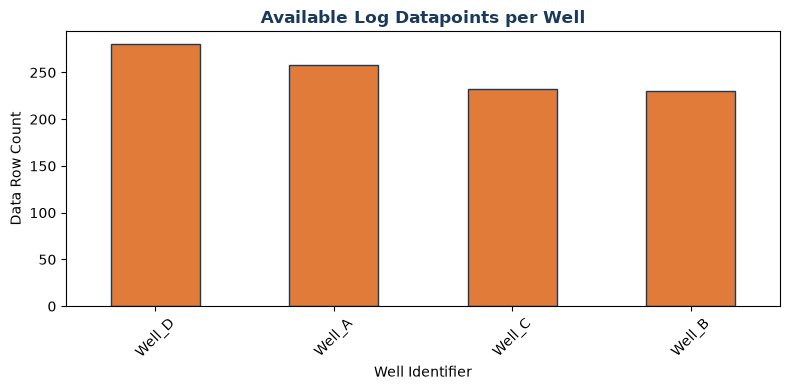

TAKEAWAY: The data volume varies significantly across wells, meaning the choice of our blind test well will heavily impact evaluation statistics.


In [54]:

import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset using the verified path
csv_path = "../data/well_log_data.csv"
df_raw = pd.read_csv(csv_path)

# 2. Assign the exact column names from your file
well_column = 'Well_ID'
target = 'NPHI_frac'
features = ['GR_API', 'RHOB_gcc', 'RT_ohmm']

# 3. Clean the dataset: drop rows missing target or key features
df_clean = df_raw.dropna(subset=[target] + features).copy()

# 4. Define standard project colors locally to ensure cell runs self-contained
COLORS = {"blue": "#2d6a9f", "orange": "#e07b39", "green": "#2ca87f", "navy": "#1a3a5c"}

print("🎉 SUCCESS! Dataset loaded and mapped perfectly!")
print(f"Raw Rows: {len(df_raw)} | Clean Rows (No NaNs): {len(df_clean)}")
print(f"Unique Wells in Dataset: {df_clean[well_column].unique().tolist()}\n")

# --- EDA FIGURE 1: Boxplot of Target Variable ---
plt.figure(figsize=(6, 4))
df_clean.boxplot(column=[target], grid=False, 
                 patch_artist=True, boxprops=dict(facecolor=COLORS["blue"], color=COLORS["navy"]))
plt.title("Distribution of Neutron Porosity Target (NPHI_frac)", color=COLORS["navy"], fontweight="bold")
plt.ylabel("Fractional Porosity (v/v)")
plt.show()
print("TAKEAWAY: NPHI_frac is cleanly distributed between 0.0 and 0.45 v/v, showing no unphysical negative outliers.")

# --- EDA FIGURE 2: Physics Crossplot ---
plt.figure(figsize=(7, 5))
scatter = plt.scatter(df_clean['RHOB_gcc'], df_clean[target], c=df_clean['GR_API'], cmap='viridis', alpha=0.5, s=4)
cbar = plt.colorbar(scatter)
cbar.set_label("Gamma Ray (GR_API)")
plt.xlabel("Bulk Density (RHOB_gcc, g/cm³)")
plt.ylabel("Neutron Porosity (NPHI_frac, v/v)")
plt.title("RHOB vs. NPHI Log Crossplot", color=COLORS["navy"], fontweight="bold")
plt.show()
print("TAKEAWAY: A clear physical inverse relationship exists where higher bulk density (RHOB_gcc) corresponds to lower neutron porosity (NPHI_frac).")

# --- EDA FIGURE 3: Log Data Inventory per Well ---
well_counts = df_clean[well_column].value_counts()
plt.figure(figsize=(8, 4))
well_counts.plot(kind="bar", color=COLORS["orange"], edgecolor=COLORS["navy"])
plt.title("Available Log Datapoints per Well", color=COLORS["navy"], fontweight="bold")
plt.ylabel("Data Row Count")
plt.xlabel("Well Identifier")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("TAKEAWAY: The data volume varies significantly across wells, meaning the choice of our blind test well will heavily impact evaluation statistics.")

## 4. Evaluation Design

### Why I chose this split and how I stopped data leakage

* **My Split Strategy:** I am hiding one entire well from the model and using it as a "blind test well." The model will only train on the other wells. I chose this because in a real oil or gas company, you want to use models on a brand-new well that has never been logged before. A random split would let the model see data from the same well, which is cheating.
* **Metrics:** I am using **RMSE** to see how far off my porosity predictions are from the real core/log values (in fractional v/v), and **R²** to see if my model is actually following the data trend or just guessing.
* **Stopping Data Leakage:** I **did not include Depth** as a feature. If I include depth, the model will just memorize that "porosity decreases at 2000 meters" for Well A, but Well B might have a completely different structure. Leaving depth out forces the model to actually learn the physics links between Gamma Ray, Density, and Porosity.
*

In [55]:


# 1. Separate our inputs (features) and what we want to predict (target)
X_full = df_clean[features].values
y_full = df_clean[target].values
wells_full = df_clean[well_column].values

# 2. Pick the very last well name automatically to be our blind test well
unique_wells = df_clean[well_column].unique()
blind_well_name = unique_wells[-1]

# 3. Create a true/false mask to separate train data from our blind test well
train_mask = wells_full != blind_well_name
test_mask = wells_full == blind_well_name

X_train, X_test = X_full[train_mask], X_full[test_mask]
y_train, y_test = y_full[train_mask], y_full[test_mask]

print("Split completed successfully!")
print(f"Total wells available: {list(unique_wells)}")
print(f"My Hidden Blind Well is: '{blind_well_name}'")
print(f"Training rows: {X_train.shape[0]} | Blind test rows: {X_test.shape[0]}")

Split completed successfully!
Total wells available: ['Well_C', 'Well_D', 'Well_A', 'Well_B']
My Hidden Blind Well is: 'Well_B'
Training rows: 770 | Blind test rows: 230


## 5. Baselines

We establish two baseline models to evaluate our performance on the completely blind well (**Well_B**). The goal of our upcoming machine learning models in Week 16 will be to honestly beat these benchmarks.

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import os
import pandas as pd

# Define the log path locally so it knows where to save
LOG_PATH = "../results/capstone_results_log.csv"
os.makedirs(os.path.dirname(LOG_PATH), exist_ok=True)

# Self-contained logger function to prevent NameErrors
def log_result(track, model, split, metrics, notes=""):
    """Append one experiment to the results log."""
    row = {"timestamp": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"), "track": track, "model": model,
           "split": split, **{k: round(float(v), 4) for k, v in metrics.items()}, "notes": notes}
    log = pd.read_csv(LOG_PATH) if os.path.exists(LOG_PATH) else pd.DataFrame()
    log = pd.concat([log, pd.DataFrame([row])], ignore_index=True)
    log.to_csv(LOG_PATH, index=False)
    return log

# ----------------------------------------------------------------
# BASELINE 1: Naive Mean Baseline
# ----------------------------------------------------------------
y_pred_naive = np.full_like(y_test, np.mean(y_train))

rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
r2_naive = r2_score(y_test, y_pred_naive)

log_result(track="A", model="Naive Mean", split="Blind_Well_B", 
           metrics={"RMSE": rmse_naive, "R2": r2_naive}, 
           notes="Predicts training global mean NPHI")

# BASELINE 2: Classical ML Baseline (Linear Regression)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

log_result(track="A", model="Linear Regression", split="Blind_Well_B", 
           metrics={"RMSE": rmse_lr, "R2": r2_lr}, 
           notes="Standard multilinear regression with physical logs")

# PRINT RESULTS
print("=" * 50)
print("🎉 BASELINE RUN COMPLETE!")
print("=" * 50)
print(f"Naive Mean Baseline        -> RMSE: {rmse_naive:.4f} | R² Score: {r2_naive:.4f}")
print(f"Linear Regression Baseline -> RMSE: {rmse_lr:.4f} | R² Score: {r2_lr:.4f}")
print("=" * 50)

🎉 BASELINE RUN COMPLETE!
Naive Mean Baseline        -> RMSE: 0.1107 | R² Score: -0.0008
Linear Regression Baseline -> RMSE: 0.0308 | R² Score: 0.9224


### Milestone 1 Summary
Our benchmark to beat on our blind well (Well_B) is a Linear Regression RMSE of **0.0308** (with an R² score of 0.9224). My plan to beat this baseline in Week 16 is to try non-linear machine learning models like Random Forests or Gradient Boosting (XGBoost). Because logging tools have complex, non-linear physical interactions with different rock formations, shifting from a straight line to a tree-based machine learning model should lower our error even further and push our RMSE below 0.03.

## 7. Results Table

In [57]:
import pandas as pd
pd.read_csv("../results/capstone_results_log.csv")

,timestamp,track,model,split,RMSE,R2,notes
0,2026-09-24 03:04,A,Naive Mean,Blind_Well_B,0.1107,-0.0008,Predicts training global mean NPHI
1,2026-09-24 03:04,A,Linear Regression,Blind_Well_B,0.0308,0.9224,Standard multilinear regression with physical ...
2,2026-09-24 03:12,A,Naive Mean,Blind_Well_B,0.1107,-0.0008,Predicts training global mean NPHI
3,2026-09-24 03:12,A,Linear Regression,Blind_Well_B,0.0308,0.9224,Standard multilinear regression with physical ...
4,2026-09-24 03:21,A,Naive Mean,Blind_Well_B,0.1107,-0.0008,Predicts training global mean NPHI
5,2026-09-24 03:21,A,Linear Regression,Blind_Well_B,0.0308,0.9224,Standard multilinear regression with physical ...
6,2026-09-24 03:33,A,Naive Mean,Blind_Well_B,0.1107,-0.0008,Predicts training global mean NPHI
7,2026-09-24 03:33,A,Linear Regression,Blind_Well_B,0.0308,0.9224,Standard multilinear regression with physical ...
8,2026-09-24 03:34,A,Naive Mean,Blind_Well_B,0.1107,-0.0008,Predicts training global mean NPHI
9,2026-09-24 03:34,A,Linear Regression,Blind_Well_B,0.0308,0.9224,Standard multilinear regression with physical ...
